#  Customer Churn Prediction

## 1. Project Overview & Introduction

### 🔹 Problem Statement / Motivation:  
Customer churn (i.e., the rate at which customers discontinue their service or product) poses a significant and persistent challenge for telecommunication companies. In a highly competitive market saturated with numerous service providers, customer acquisition costs are often substantially higher than customer retention costs. A high churn rate directly translates to:

Significant Revenue Loss: Each churned customer represents lost recurring revenue, impacting the company's financial stability and growth projections.

Reduced Customer Lifetime Value (CLTV): Churn diminishes the average CLTV, as customers are not retained long enough to realize their full revenue potential.

Increased Marketing & Acquisition Costs: To offset churn, companies are forced to invest more heavily in acquiring new customers, which can be an inefficient use of resources if underlying retention issues are not addressed.

Brand Erosion & Negative Word-of-Mouth: Dissatisfied or disengaged customers who churn may spread negative sentiments, damaging the company's reputation and deterring potential new customers.

Traditional reactive approaches to churn, such as exit surveys or last-ditch efforts, are often insufficient as they occur after the customer has already decided to leave. There is a critical need for a proactive and data-driven approach to identify customers at high risk of churning before they actually do.

This project aims to address this problem by leveraging historical customer data to develop a robust machine learning model capable of accurately predicting which customers are likely to churn. By identifying these "at-risk" customers early, the telecom company can implement targeted retention strategies, such as personalized offers, proactive customer support, or service adjustments, thereby mitigating revenue loss, enhancing customer satisfaction, and improving overall business profitability.

### 🔹 Dataset Description:
The dataset contains 3,738 customer records from a telecom provider. It includes customer demographics, service details, account information, and a target column `Churn`.

- Total Rows: 3,738  
- Features: 21  
- Target: `Churn` (Yes/No)

### 🔹 Goals / Objectives:
- Explore customer behavior and churn patterns  
- Build a model to predict churn  
- Identify key drivers of churn  
- Suggest actionable business recommendations

### 🔹 Technologies Used:
- Python  
- Pandas, NumPy  
- Matplotlib, Seaborn  
- Scikit-learn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.  Exploratory Data Analysis (EDA) Insights

In this section, we explore the dataset to uncover key patterns, clean anomalies, and prepare the data for modeling.


In [2]:
df = pd.read_excel(r'C:\Users\TANVEER\Documents\Altamash\Customer-Churn-Prediction\Data\Raw\Customer Churn.xlsx')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4495-LHSSK,Female,No,No,Yes,18,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,57.65,992.70,No
1,5791-KAJFD,Female,No,Yes,Yes,56,Yes,Yes,DSL,Yes,...,Yes,No,No,Yes,One year,Yes,Bank transfer (automatic),68.75,3808.00,No
2,3721-CNZHX,Male,No,No,No,15,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.80,304.60,No
3,4000-VGMQP,Male,No,Yes,Yes,38,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),78.95,2862.55,No
4,2194-IIQOF,Female,No,Yes,No,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),89.30,6388.65,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3738 entries, 0 to 3737
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        3738 non-null   str    
 1   gender            3738 non-null   str    
 2   SeniorCitizen     3738 non-null   str    
 3   Partner           3738 non-null   str    
 4   Dependents        3738 non-null   str    
 5   tenure            3738 non-null   int64  
 6   PhoneService      3738 non-null   str    
 7   MultipleLines     3738 non-null   str    
 8   InternetService   3738 non-null   str    
 9   OnlineSecurity    3738 non-null   str    
 10  OnlineBackup      3738 non-null   str    
 11  DeviceProtection  3738 non-null   str    
 12  TechSupport       3738 non-null   str    
 13  StreamingTV       3738 non-null   str    
 14  StreamingMovies   3738 non-null   str    
 15  Contract          3738 non-null   str    
 16  PaperlessBilling  3738 non-null   str    
 17  Paymen

In [5]:
df.drop('customerID',axis=1,inplace=True)

In [6]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        5
Churn               0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,3733.000000,3733.000000,3733.000000
mean,27.935441,67.844133,2054.323239
std,24.125728,28.945812,2193.355619
min,1.000000,18.400000,18.850000
25%,5.000000,45.300000,273.000000
50%,21.000000,74.750000,1151.550000
75%,49.000000,90.650000,3361.050000
max,72.000000,118.750000,8684.800000


In [9]:
import seaborn as sns

gender


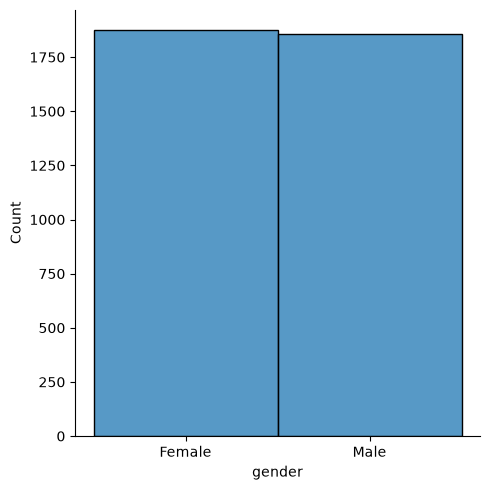

SeniorCitizen


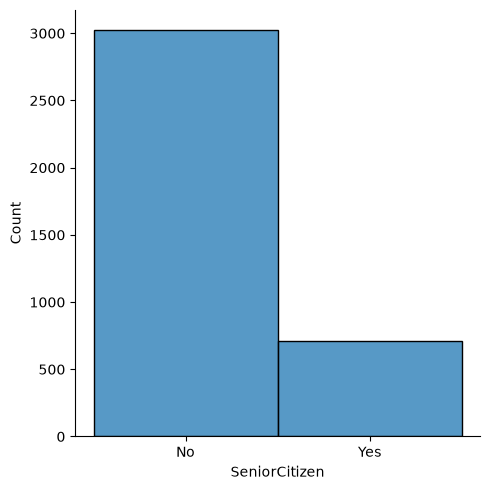

Partner


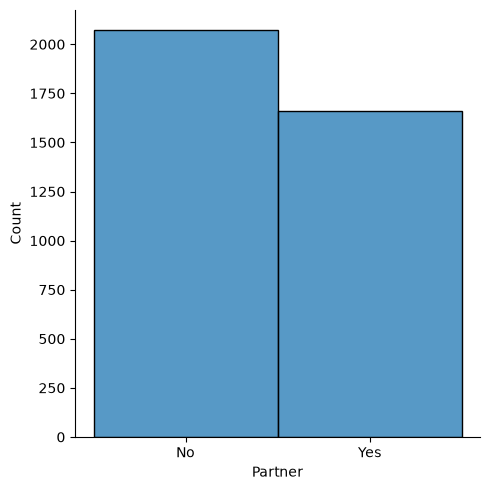

Dependents


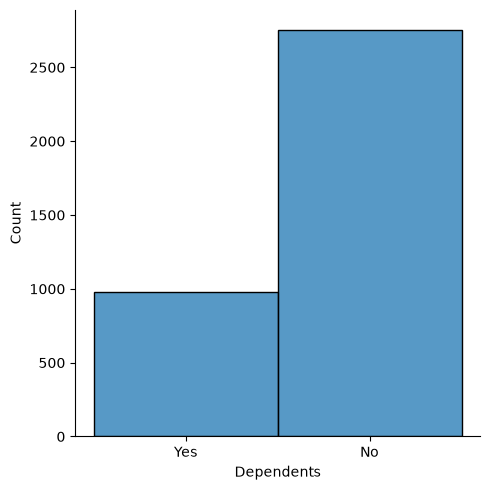

tenure


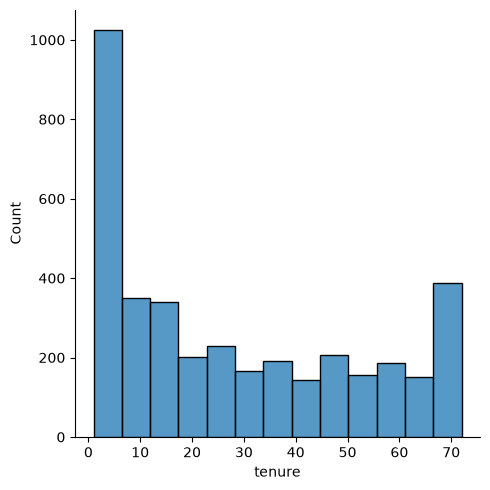

PhoneService


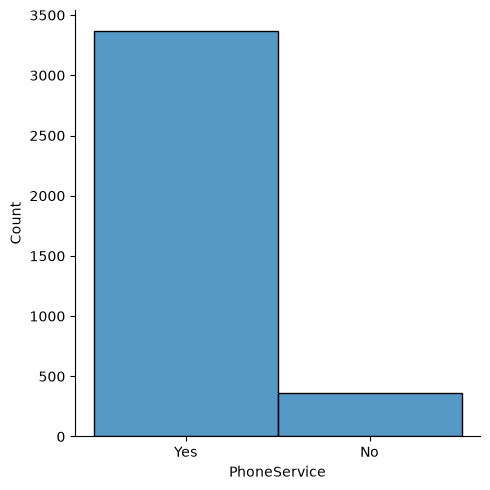

MultipleLines


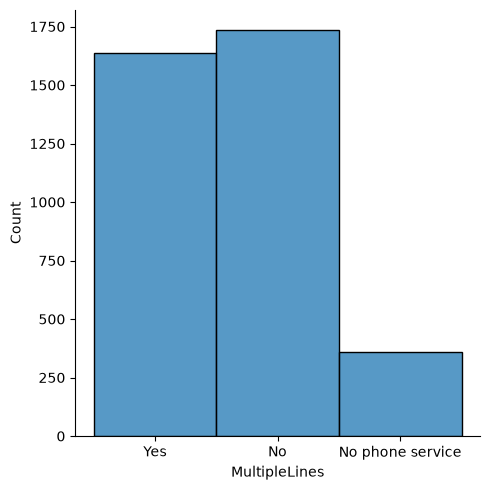

InternetService


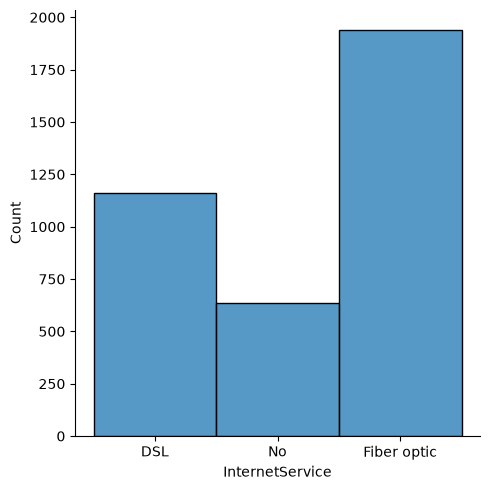

OnlineSecurity


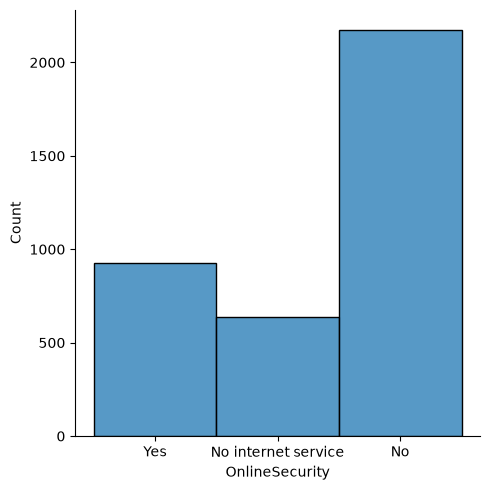

OnlineBackup


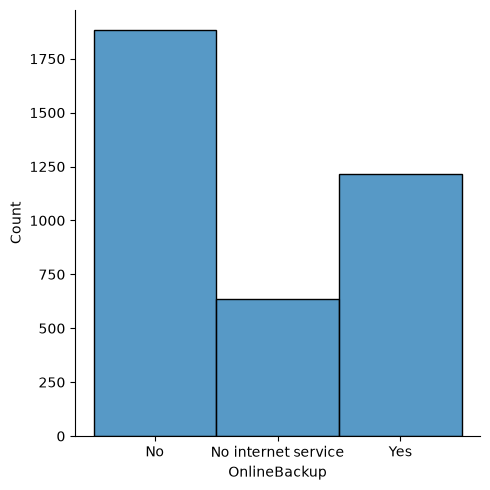

DeviceProtection


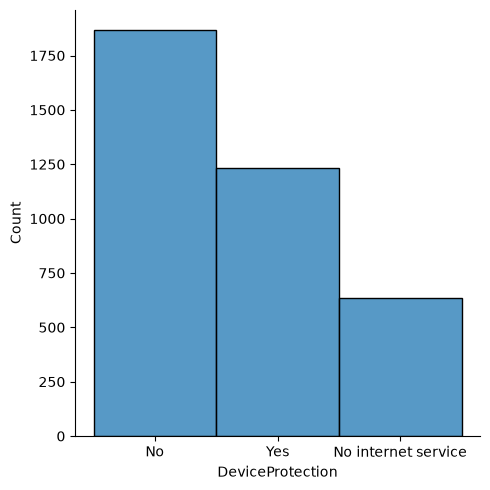

TechSupport


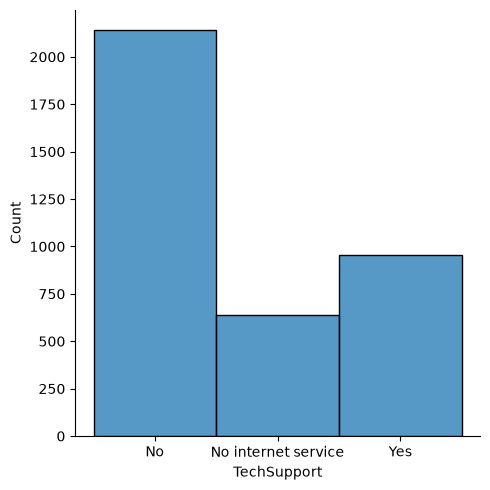

StreamingTV


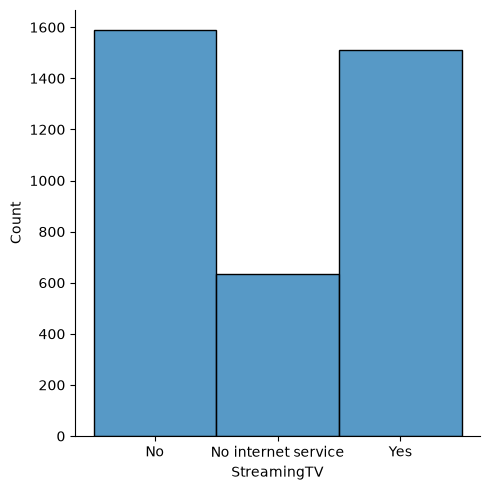

StreamingMovies


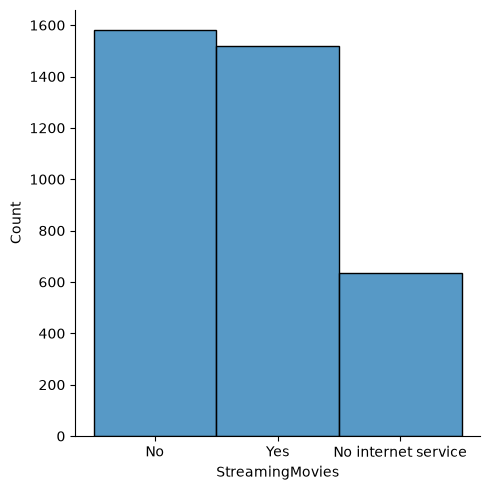

Contract


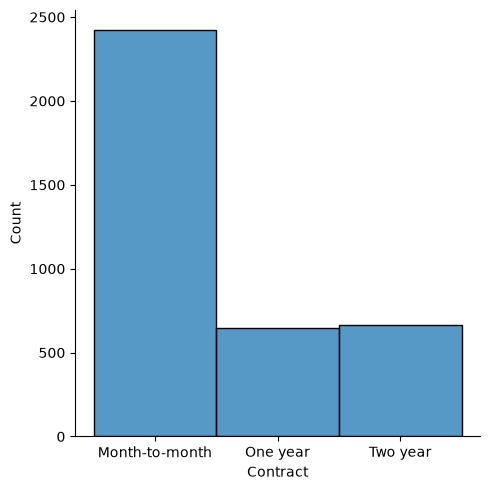

PaperlessBilling


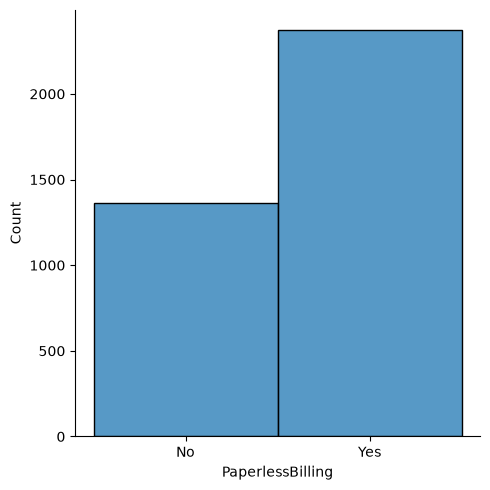

PaymentMethod


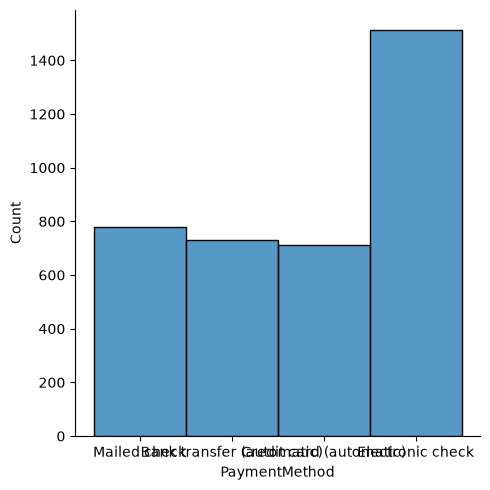

MonthlyCharges


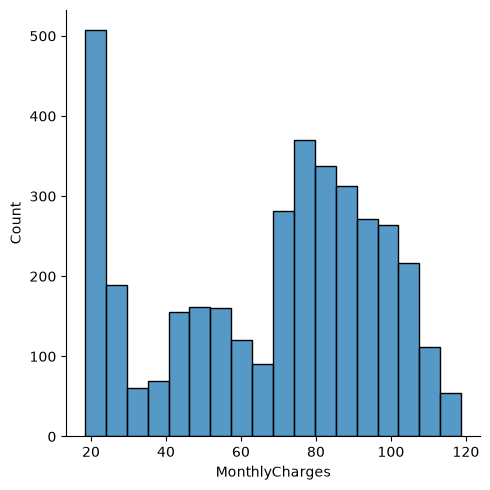

TotalCharges


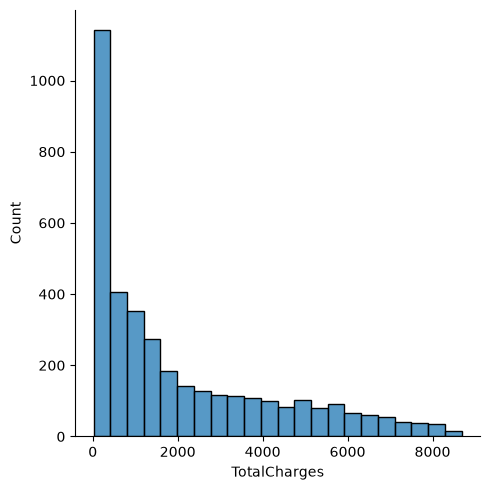

Churn


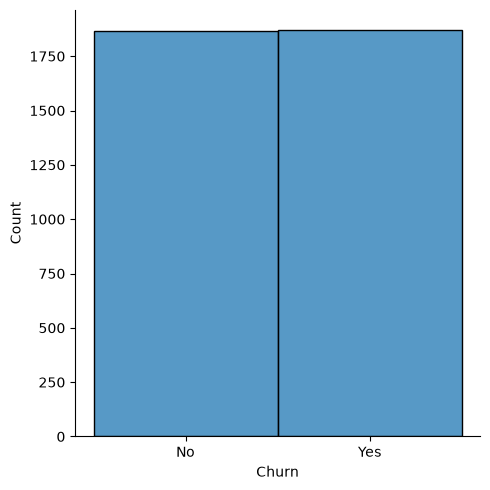

In [10]:
for col_name in df.columns:
    print(col_name)
    sns.displot(df[col_name])
    plt.show()

### Churn by Contract Type:

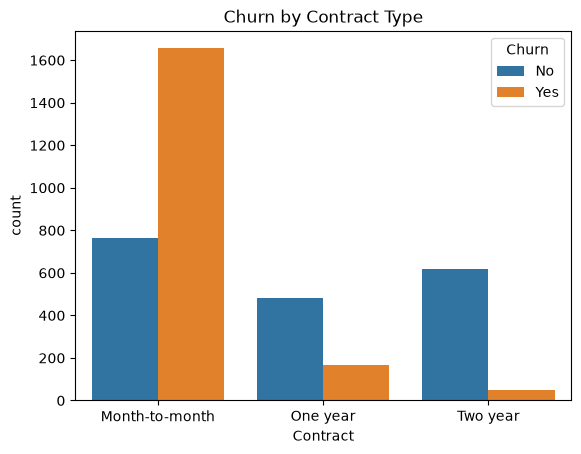

In [11]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.show()

### Tenure vs Churn:


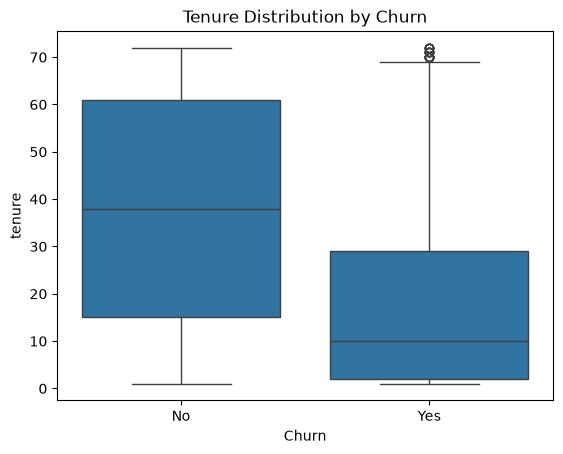

In [12]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.show()

### Churn vs Monthly charges

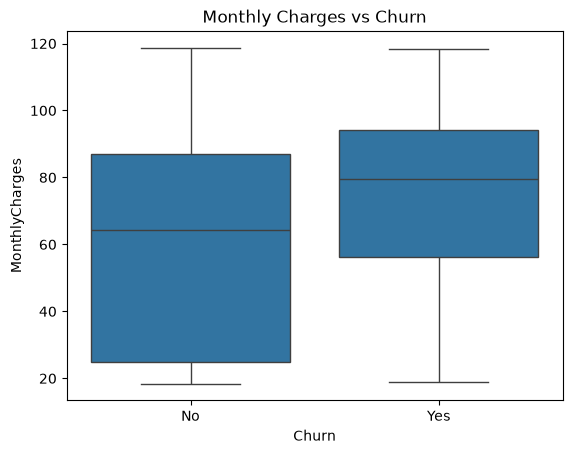

In [13]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

## Exploratory Data Analysis (EDA) Insights  
Through Exploratory Data Analysis, we uncovered critical patterns influencing customer churn:

Data Preprocessing: Handled 5 missing values in TotalCharges by dropping rows. The Churn target variable is well-balanced.

Demographics: Senior citizens, and customers without partners or dependents, show higher churn rates. Gender does not appear to be a significant factor.

Tenure & Contract: New customers (low tenure) and those on month-to-month contracts exhibit significantly higher churn. Long-term contracts are strong retention factors.

Services & Charges:

Customers lacking value-added services (e.g., Online Security, Tech Support) are more prone to churn.

Fiber optic internet users have a higher churn rate.

Higher MonthlyCharges and Electronic Check payment methods correlate with increased churn.


## Feature Engineering:

In [14]:
## Total Services:

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_columns:
    df[col + "_flag"] = (
        df[col].astype(str).str.lower().isin(["yes"])
    ).astype(int)

df["ServiceCount"] = df[
    [col + "_flag" for col in service_columns]
].sum(axis=1)

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Churn,PhoneService_flag,MultipleLines_flag,OnlineSecurity_flag,OnlineBackup_flag,DeviceProtection_flag,TechSupport_flag,StreamingTV_flag,StreamingMovies_flag,ServiceCount
0,Female,No,No,Yes,18,Yes,Yes,DSL,Yes,No,...,No,1,1,1,0,0,0,0,0,3
1,Female,No,Yes,Yes,56,Yes,Yes,DSL,Yes,No,...,No,1,1,1,0,1,0,0,1,5
2,Male,No,No,No,15,Yes,No,No,No internet service,No internet service,...,No,1,0,0,0,0,0,0,0,1
3,Male,No,Yes,Yes,38,Yes,Yes,DSL,No,Yes,...,No,1,1,0,1,1,0,1,1,6
4,Female,No,Yes,No,71,Yes,Yes,DSL,Yes,Yes,...,No,1,1,1,1,1,1,1,1,8


In [16]:
def tenure_creation(data):
    if data < 12:
        return "Below 1 year"
    elif data < 36:
        return "Below 3 years"
    elif data < 60:
        return "Below 5 years"
    else:
        return "oldest Customers" 

df["tenure group"] = df["tenure"].apply(tenure_creation)
df


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PhoneService_flag,MultipleLines_flag,OnlineSecurity_flag,OnlineBackup_flag,DeviceProtection_flag,TechSupport_flag,StreamingTV_flag,StreamingMovies_flag,ServiceCount,tenure group
0,Female,No,No,Yes,18,Yes,Yes,DSL,Yes,No,...,1,1,1,0,0,0,0,0,3,Below 3 years
1,Female,No,Yes,Yes,56,Yes,Yes,DSL,Yes,No,...,1,1,1,0,1,0,0,1,5,Below 5 years
2,Male,No,No,No,15,Yes,No,No,No internet service,No internet service,...,1,0,0,0,0,0,0,0,1,Below 3 years
3,Male,No,Yes,Yes,38,Yes,Yes,DSL,No,Yes,...,1,1,0,1,1,0,1,1,6,Below 5 years
4,Female,No,Yes,No,71,Yes,Yes,DSL,Yes,Yes,...,1,1,1,1,1,1,1,1,8,oldest Customers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3733,Male,No,Yes,Yes,72,Yes,No,DSL,Yes,Yes,...,1,0,1,1,0,1,1,0,5,oldest Customers
3734,Female,Yes,Yes,No,36,Yes,Yes,Fiber optic,No,Yes,...,1,1,0,1,0,0,1,0,4,Below 5 years
3735,Male,No,No,No,26,Yes,No,No,No internet service,No internet service,...,1,0,0,0,0,0,0,0,1,Below 3 years
3736,Male,Yes,No,No,43,Yes,No,Fiber optic,No,No,...,1,0,0,0,0,0,1,1,3,Below 5 years


In [17]:
## Average Monthy Value

df["AvgMonthlyValue"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, np.nan)
)



In [18]:
df[["AvgMonthlyValue","TotalCharges"]]

,AvgMonthlyValue,TotalCharges
0,55.150000,992.70
1,68.000000,3808.00
2,20.306667,304.60
3,75.330263,2862.55
4,89.980986,6388.65
...,...,...
3733,67.435417,4855.35
3734,91.695833,3301.05
3735,17.588462,457.30
3736,89.691860,3856.75


# **ML :**

In [19]:
X = df.drop(
    columns=["Churn", "customerID"],
    errors="ignore"
)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [20]:
# Numeric and Categorical Features:

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

C:\Users\TANVEER\AppData\Local\Temp\ipykernel_612\4193191454.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100, stratify = y)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [23]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MultipleLines_flag,OnlineSecurity_flag,OnlineBackup_flag,DeviceProtection_flag,TechSupport_flag,StreamingTV_flag,StreamingMovies_flag,ServiceCount,tenure group,AvgMonthlyValue
0,Female,No,No,Yes,18,Yes,Yes,DSL,Yes,No,...,1,1,0,0,0,0,0,3,Below 3 years,55.150000
1,Female,No,Yes,Yes,56,Yes,Yes,DSL,Yes,No,...,1,1,0,1,0,0,1,5,Below 5 years,68.000000
2,Male,No,No,No,15,Yes,No,No,No internet service,No internet service,...,0,0,0,0,0,0,0,1,Below 3 years,20.306667
3,Male,No,Yes,Yes,38,Yes,Yes,DSL,No,Yes,...,1,0,1,1,0,1,1,6,Below 5 years,75.330263
4,Female,No,Yes,No,71,Yes,Yes,DSL,Yes,Yes,...,1,1,1,1,1,1,1,8,oldest Customers,89.980986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3733,Male,No,Yes,Yes,72,Yes,No,DSL,Yes,Yes,...,0,1,1,0,1,1,0,5,oldest Customers,67.435417
3734,Female,Yes,Yes,No,36,Yes,Yes,Fiber optic,No,Yes,...,1,0,1,0,0,1,0,4,Below 5 years,91.695833
3735,Male,No,No,No,26,Yes,No,No,No internet service,No internet service,...,0,0,0,0,0,0,0,1,Below 3 years,17.588462
3736,Male,Yes,No,No,43,Yes,No,Fiber optic,No,No,...,0,0,0,0,0,1,1,3,Below 5 years,89.691860


### Logistic Regression for Baseline:

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['gender','SeniorCitizen','Partner',...,'ServiceCount','tenure group', 'AvgMonthlyValue']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [25]:
lr_pred = lr_pipeline.predict(X_test)

lr_probability = lr_pipeline.predict_proba(X_test)[:,1]
lr_probability

array([0.31783853, 0.83205045, 0.57257443, 0.86615956, 0.04506481,
       0.28867561, 0.03566136, 0.80952192, 0.10654977, 0.61425589,
       0.83218557, 0.73619418, 0.59807374, 0.78227694, 0.59465077,
       0.09253467, 0.57107494, 0.12057527, 0.83481884, 0.81575698,
       0.58292183, 0.91907079, 0.59743781, 0.89494437, 0.17187108,
       0.56066266, 0.28260368, 0.02372919, 0.8349352 , 0.00953398,
       0.87849081, 0.38850909, 0.93982257, 0.89530457, 0.8396272 ,
       0.60865897, 0.13897731, 0.85051159, 0.54769478, 0.77697699,
       0.22858151, 0.73407858, 0.84179345, 0.80849189, 0.94255375,
       0.90385466, 0.88903783, 0.92085984, 0.83271154, 0.4119438 ,
       0.05131295, 0.00745818, 0.42992742, 0.35719592, 0.8049795 ,
       0.02094344, 0.35285271, 0.59444853, 0.75180175, 0.06334822,
       0.69869319, 0.01163022, 0.83855158, 0.81413008, 0.759171  ,
       0.93172146, 0.18410522, 0.01576856, 0.76165057, 0.87318987,
       0.48691075, 0.84296316, 0.0399851 , 0.06980155, 0.27032

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77       373
           1       0.76      0.81      0.78       374

    accuracy                           0.78       747
   macro avg       0.78      0.78      0.78       747
weighted avg       0.78      0.78      0.78       747



## Feature Selection :

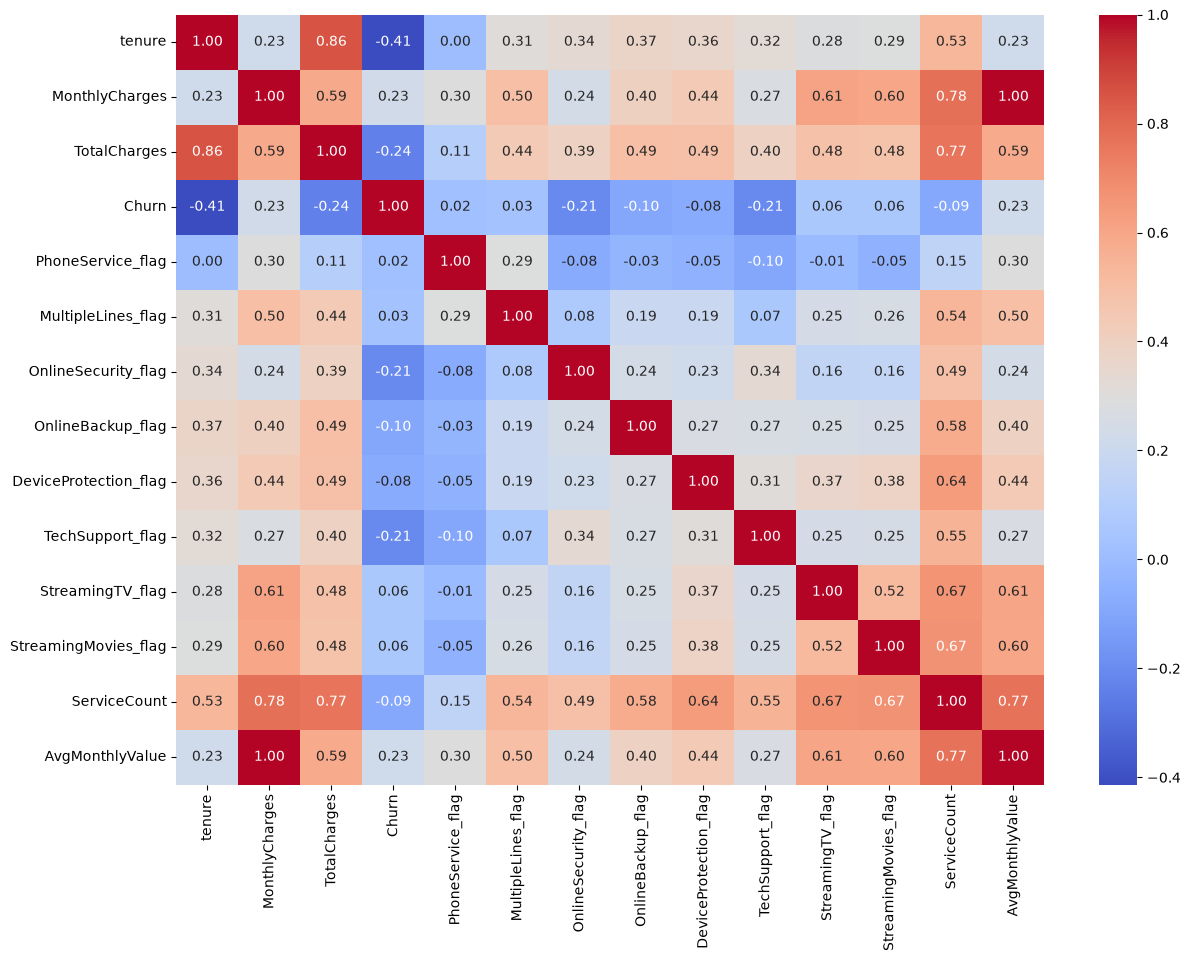

In [27]:
# Getting more to know using heatmap

import seaborn as sns
plt.figure(figsize=(14,10))
corr_df = df.copy()
corr_df["Churn"] = corr_df["Churn"].map({"No": 0, "Yes": 1})

sns.heatmap(
    corr_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.show()

In [28]:
df.drop('tenure',axis=1,inplace=True)   # Droping it because we already did it in tenure group and it's showing high correlation


## XGBoost Model:

In [29]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['gender','SeniorCitizen','Partner',...,'ServiceCount','tenure group', 'AvgMonthlyValue']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [30]:
xgb_pred = xgb_pipeline.predict(X_test)

xgb_probability = (
    xgb_pipeline
    .predict_proba(X_test)[:, 1]
)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

def evaluate_model(y_true, pred, probability):

    print("Accuracy:",
          accuracy_score(y_true, pred))

    print("Precision:",
          precision_score(y_true, pred))

    print("Recall:",
          recall_score(y_true, pred))

    print("F1:",
          f1_score(y_true, pred))

    print("ROC-AUC:",
          roc_auc_score(y_true, probability))

    print(
        classification_report(
            y_true,
            pred
        )
    )

In [32]:
evaluate_model(
    y_test,
    xgb_pred,
    xgb_probability
)

Accuracy: 0.7804551539491299
Precision: 0.7692307692307693
Recall: 0.8021390374331551
F1: 0.7853403141361257
ROC-AUC: 0.8590593683244685
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       373
           1       0.77      0.80      0.79       374

    accuracy                           0.78       747
   macro avg       0.78      0.78      0.78       747
weighted avg       0.78      0.78      0.78       747



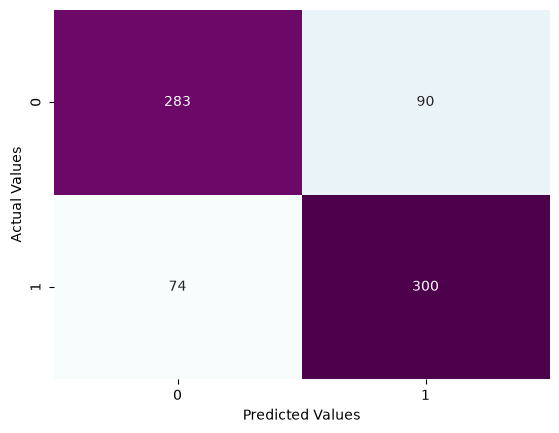

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       373
           1       0.77      0.80      0.79       374

    accuracy                           0.78       747
   macro avg       0.78      0.78      0.78       747
weighted avg       0.78      0.78      0.78       747

Accuracy of the model:  0.7804551539491299


In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(y_test,xgb_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(y_test,xgb_pred))

acc=accuracy_score(y_test,xgb_pred)
print("Accuracy of the model: ",acc)

## Cross Validation:

In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

[0.84805594 0.84839644 0.85461857 0.81757218 0.86728049]
0.8471847247018942


### Parameter Search:

In [35]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``R

In [36]:
best_model = search.best_estimator_

print(search.best_params_)

{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}


### Final Model:

## Key Insights from Customer Churn Prediction Model:

This project focused on developing a predictive model to identify customers at high risk of churn, a critical challenge for telecommunication companies. The insights derived from the model's performance are crucial for strategic customer retention.

- **Model Accuracy**: The predictive model achieved an overall accuracy of **77.78%**, indicating its general effectiveness in classifying customers as either likely to churn or not.
- **Non-Churner Identification (Class 0)**:
    - **Precision of 0.79**: When the model predicts a customer will **not** churn, it is correct 79% of the time. This highlights the model's reliability in identifying stable customers.
    - **Recall of 0.76**: The model successfully identifies 76% of all actual non-churning customers.
- **Churner Identification (Class 1)**:
    - **Precision of 0.77**: When the model predicts a customer **will** churn, it is correct 77% of the time. This indicates a good level of confidence in the model's positive predictions for churn.
    - **Recall of 0.80**: The model is particularly effective at capturing churning customers, identifying 80% of all actual churners. This high recall for the churn class is vital as it minimizes the number of actual churners missed, allowing for timely intervention.
- **Balanced Performance**: With F1-scores of 0.77 for non-churners and 0.78 for churners, the model demonstrates a balanced ability to predict both classes, signifying its robustness in handling the classification task.
- **Data Foundation**: The initial data preparation steps, including handling missing 'TotalCharges' values and cleaning the dataset to 3,733 records, laid a solid groundwork for reliable model training.

---

## Final Conclusion :

The Customer Churn Prediction model has been successfully developed and evaluated, demonstrating a strong capability to predict customer churn with **an accuracy of nearly 78%**. Its particularly notable **recall of 0.80 for churning customers** provides a powerful tool for telecommunication companies, enabling them to proactively identify the vast majority of customers at risk of discontinuing service.

This predictive power offers a robust foundation for **targeted intervention strategies**. By leveraging these insights, companies can deploy personalized retention campaigns, offer timely incentives, and optimize resource allocation towards at-risk segments, thereby significantly reducing churn rates. This data-driven approach is instrumental in enhancing customer lifetime value, minimizing revenue loss, and fostering sustainable business growth in a competitive market. Moving forward, integrating these predictions into a continuous monitoring system and identifying specific churn drivers would further solidify the strategic impact of this project.


## **Retention Strategy :**

In [60]:
xgb_probability = xgb_pipeline.predict_proba(X_test)[:, 1]
print("XGBoost Probabilities:",xgb_probability)


XGBoost Probabilities: [0.27604932 0.85551584 0.34200886 0.9529706  0.03763273 0.20781136
 0.05609136 0.8344881  0.08479913 0.61962444 0.8550906  0.72620887
 0.61550707 0.8129756  0.39614072 0.06078504 0.86592513 0.21588147
 0.8616787  0.82276326 0.3642869  0.9826141  0.6435714  0.9145007
 0.04627839 0.52603877 0.36116546 0.0568017  0.83012533 0.00792702
 0.85769045 0.18842809 0.9818076  0.9561325  0.81448364 0.65337825
 0.16865319 0.92010224 0.5883365  0.5977213  0.11382256 0.7205644
 0.88506967 0.7857461  0.97894603 0.8780129  0.8337029  0.98807806
 0.75194824 0.6218133  0.02976752 0.00490961 0.50895905 0.28293413
 0.8724204  0.05817448 0.3132346  0.2646037  0.73540646 0.03270349
 0.73517895 0.00589939 0.935228   0.9537716  0.8163908  0.9536224
 0.14641233 0.00738195 0.69086677 0.92932594 0.50190866 0.8696618
 0.03882421 0.0662417  0.28594774 0.9209538  0.47216862 0.568431
 0.81865364 0.8563563  0.00871815 0.02700398 0.65355647 0.48761237
 0.35024542 0.9829884  0.00886364 0.17432125 

### **Threshold Analysis:**

In [76]:


# prediction = probability >= 0.5

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    xgb_probability
)

# print("Precision:", precision)
# print("Recall:", recall)
# print("Thresholds:", thresholds.round(1))



In [77]:
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds_to_test:

    y_pred = (xgb_probability >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Customers_Flagged": y_pred.sum(),
        "Flagged_%": y_pred.mean() * 100,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

print(threshold_results)

   Threshold  Customers_Flagged  Flagged_%  Precision    Recall        F1
0        0.3                477  63.855422   0.710692  0.906417  0.796710
1        0.4                433  57.965194   0.741339  0.858289  0.795539
2        0.5                390  52.208835   0.769231  0.802139  0.785340
3        0.6                337  45.113788   0.807122  0.727273  0.765120
4        0.7                286  38.286479   0.832168  0.636364  0.721212


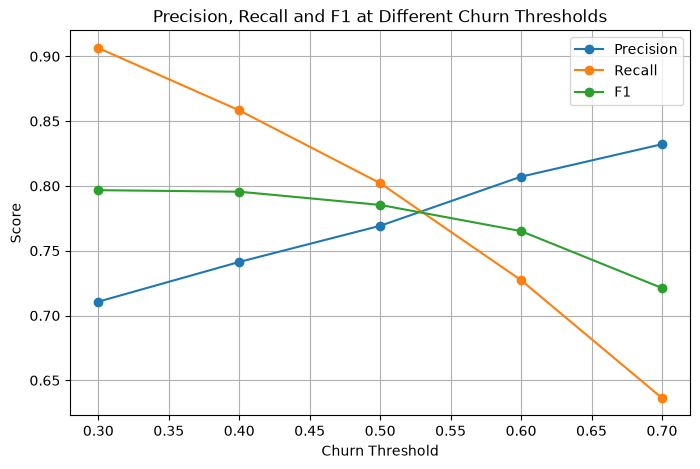

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"

)

plt.xlabel("Churn Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 at Different Churn Thresholds")
plt.legend()
plt.grid()
plt.show()

In [79]:
selected_threshold = 0.55

y_pred_final = (
    xgb_probability >= selected_threshold
).astype(int)

print(y_pred_final)

[0 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1 0
 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0
 0 1 0 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 1
 1 1 0 1 0 0 0 1 0 1 0 1 0 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 0
 1 0 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 1 0
 1 1 0 0 1 0 1 1 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0
 1 0 0 1 0 1 1 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0
 0 1 1 1 1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 1 0
 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0 0 1 0 0 1
 0 1 0 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 1
 0 0 1 1 1 1 0 0 1 0 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 1 0 0 1 0 1 0
 1 1 1 1 0 1 1 0 0 1 1 0 1 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 1 1
 1 0 0 1 0 1 0 1 0 0 0 1 

### **Customer Risk Scores:**

In [80]:
customer_probability = (
    best_model.predict_proba(X)[:, 1]
)

print("Customer Probabilities:", customer_probability.round(2))

Customer Probabilities: [0.34 0.18 0.11 ... 0.1  0.59 0.85]


In [81]:
risk_df = df.copy()

risk_df["ChurnProbability"] = customer_probability

In [82]:
def risk_category(prob):

    if prob >= 0.70:
        return "High Risk"

    elif prob >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"


risk_df["RiskLevel"] = (
    risk_df["ChurnProbability"]
    .apply(risk_category)
)

In [83]:
risk_df["RiskLevel"]

0          Low Risk
1          Low Risk
2          Low Risk
3          Low Risk
4          Low Risk
           ...     
3733       Low Risk
3734    Medium Risk
3735       Low Risk
3736    Medium Risk
3737      High Risk
Name: RiskLevel, Length: 3733, dtype: str

In [87]:
risk_df["MonthlyCharges"]

0       57.65
1       68.75
2       19.80
3       78.95
4       89.30
        ...  
3733    68.40
3734    91.95
3735    19.80
3736    89.55
3737    44.10
Name: MonthlyCharges, Length: 3733, dtype: float64

In [86]:
## Estimate Revenue Exposure:

risk_df["RevenueAtRisk"] = (
    risk_df["MonthlyCharges"] *
    risk_df["ChurnProbability"]
)

risk_df["RevenueAtRisk"]

0       19.473775
1       12.197413
2        2.120529
3       21.003719
4        5.600513
          ...    
3733     4.078123
3734    52.370307
3735     1.991241
3736    53.246859
3737    37.521097
Name: RevenueAtRisk, Length: 3733, dtype: float64

In [100]:
def retention_segment(row): 

    if (
        row["ChurnProbability"] >= 0.70 
        and row["MonthlyCharges"] >= risk_df["MonthlyCharges"].median()
    ): 
        return "High Risk - High Value" 

    elif (
        row["ChurnProbability"] >= 0.70
        and row["tenure group"] <= "Below 1 year"
    ): 
        return "High Risk - New Customer" 

    elif row["ChurnProbability"] >= 0.70: 
        return "High Risk - General" 

    elif row["ChurnProbability"] >= 0.40: 
        return "Medium Risk" 

    else: 
        return "Low Risk" 


risk_df["RetentionSegment"] = risk_df.apply(
    retention_segment, 
    axis=1
)

### **Recommended Actions:**

In [101]:
def retention_action(row):

    if row["RetentionSegment"] == "High Risk - High Value":
        return "Priority retention offer"

    elif row["RetentionSegment"] == "High Risk - New Customer":
        return "Onboarding intervention"

    elif row["OnlineSecurity"] == "No":
        return "Promote security service"

    elif row["TechSupport"] == "No":
        return "Offer technical support"

    elif row["Contract"] == "Month-to-month":
        return "Promote long-term contract"

    else:
        return "Standard engagement"


risk_df["RecommendedAction"] = (
    risk_df.apply(
        retention_action,
        axis=1
    )
)

In [103]:
risk_df.head(20)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV_flag,StreamingMovies_flag,ServiceCount,tenure group,AvgMonthlyValue,ChurnProbability,RiskLevel,RevenueAtRisk,RetentionSegment,RecommendedAction
0,Female,No,No,Yes,Yes,Yes,DSL,Yes,No,No,...,0,0,3,Below 3 years,55.150000,0.337793,Low Risk,19.473775,Low Risk,Offer technical support
1,Female,No,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,...,0,1,5,Below 5 years,68.000000,0.177417,Low Risk,12.197413,Low Risk,Offer technical support
2,Male,No,No,No,Yes,No,No,No internet service,No internet service,No internet service,...,0,0,1,Below 3 years,20.306667,0.107097,Low Risk,2.120529,Low Risk,Standard engagement
3,Male,No,Yes,Yes,Yes,Yes,DSL,No,Yes,Yes,...,1,1,6,Below 5 years,75.330263,0.266038,Low Risk,21.003719,Low Risk,Promote security service
4,Female,No,Yes,No,Yes,Yes,DSL,Yes,Yes,Yes,...,1,1,8,oldest Customers,89.980986,0.062716,Low Risk,5.600513,Low Risk,Standard engagement
5,Female,No,No,No,Yes,No,No,No internet service,No internet service,No internet service,...,0,0,1,Below 5 years,18.785135,0.126818,Low Risk,2.510991,Low Risk,Standard engagement
6,Female,No,Yes,Yes,No,No phone service,DSL,Yes,No,Yes,...,1,1,5,Below 3 years,58.623529,0.166443,Low Risk,10.194621,Low Risk,Standard engagement
7,Male,No,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,...,0,0,1,Below 5 years,18.052326,0.098125,Low Risk,1.883993,Low Risk,Standard engagement
8,Male,No,No,No,Yes,No,No,No internet service,No internet service,No internet service,...,0,0,1,Below 1 year,19.950000,0.590052,Medium Risk,11.771538,Medium Risk,Promote long-term contract
9,Male,Yes,No,No,Yes,No,Fiber optic,No,No,No,...,0,1,2,Below 3 years,77.073333,0.835856,High Risk,66.366930,High Risk - High Value,Priority retention offer


In [114]:
## Saving Customer Risk DataFrame to CSV:

risk_df.to_csv(
    "../data/processed/customer_risk.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    best_model,
    "../models/churn_model.pkl"
)


## loading model later:
"""
model = joblib.load(
    "../models/churn_model.pkl"
)
"""

'\nmodel = joblib.load(\n    "../models/churn_model.pkl"\n)\n'